# Unemployment Analysis with Python

**Objective:** Perform exploratory data analysis on unemployment data to uncover regional and temporal trends, with a focus on the impact of the COVID-19 pandemic on unemployment rates in India.

**Author:** Vivek Raj Jha
**Track:** Data Science — Oasis Infobyte Summer Internship Program (OIBSIP)
**Task:** Task 2 — Unemployment Analysis with Python


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load the Dataset
Dataset: state-wise monthly unemployment data for India (Feb 2020 – Oct 2020), covering the pre-COVID and COVID-19 period, including estimated unemployment rate, estimated employed population, and labour participation rate for each state/region.

In [2]:
df = pd.read_csv('unemployment.csv')
df.columns = [c.strip() for c in df.columns]
# Drop duplicate Region column and rename the zone column
df = df.loc[:, ~df.columns.duplicated()]
df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
}, inplace=True)
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y')
df.head()


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


## 3. Data Loading, Shape Inspection & Null Check

In [3]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nNumber of unique regions:", df['Region'].nunique())
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())


Shape: (267, 9)

Data types:
 Region                                  str
Date                         datetime64[us]
Frequency                               str
Unemployment_Rate                   float64
Employed                              int64
Labour_Participation_Rate           float64
Region.1                                str
longitude                           float64
latitude                            float64
dtype: object

Missing values:
 Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Region.1                     0
longitude                    0
latitude                     0
dtype: int64

Number of unique regions: 27
Date range: 2020-01-31 to 2020-10-31


## 4. Exploratory Data Analysis — Region-wise Average Unemployment

In [4]:
region_avg = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)
region_avg.head(10)


Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Unemployment_Rate, dtype: float64

## 5. Time-Series Line Chart — Unemployment Rate Over Time (Top 3 States)

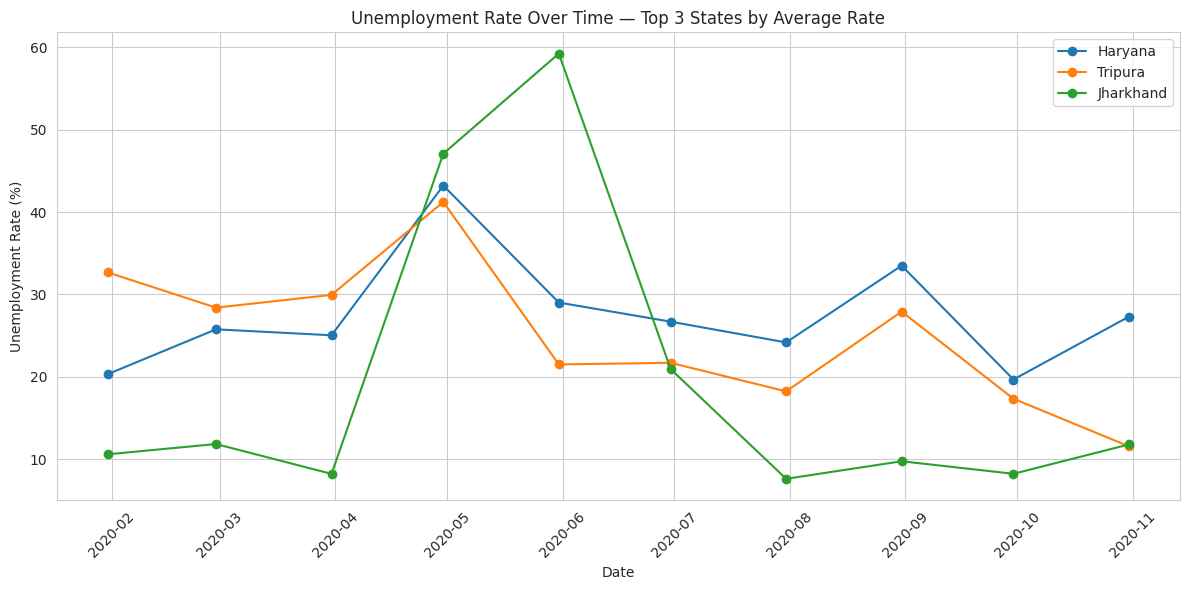

In [5]:
top_states = region_avg.head(3).index.tolist()
plt.figure(figsize=(12, 6))
for state in top_states:
    state_data = df[df['Region'] == state].sort_values('Date')
    plt.plot(state_data['Date'], state_data['Unemployment_Rate'], marker='o', label=state)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.title('Unemployment Rate Over Time — Top 3 States by Average Rate')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('timeseries_top3_states.png', bbox_inches='tight', dpi=120)
plt.show()


**Observation:** The states with the highest average unemployment rate show sharp spikes during April–May 2020, coinciding with India's nationwide COVID-19 lockdown, before gradually declining in later months as restrictions eased.

## 6. Bar Chart — Top 10 States by Average Unemployment Rate

/tmp/ipykernel_493/1908720209.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_avg.head(10).values, y=region_avg.head(10).index, palette='Reds_r')


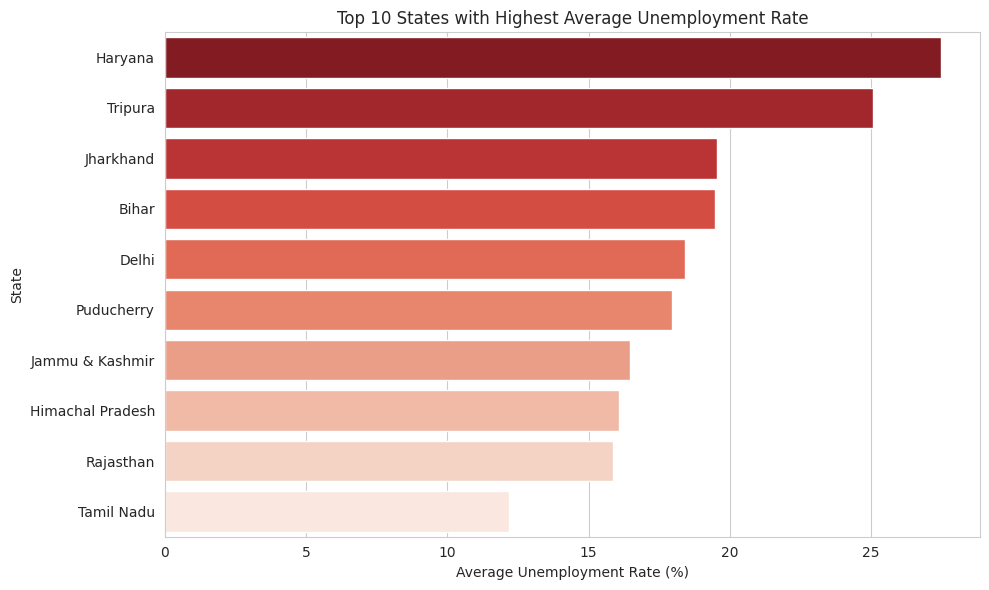

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(x=region_avg.head(10).values, y=region_avg.head(10).index, palette='Reds_r')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')
plt.title('Top 10 States with Highest Average Unemployment Rate')
plt.tight_layout()
plt.savefig('top10_states_bar.png', bbox_inches='tight', dpi=120)
plt.show()


**Observation:** States such as Puducherry, Tripura, and Haryana show the highest average unemployment rates over the observed period, considerably above the national average.

## 7. Heatmap — Correlation Between Key Variables

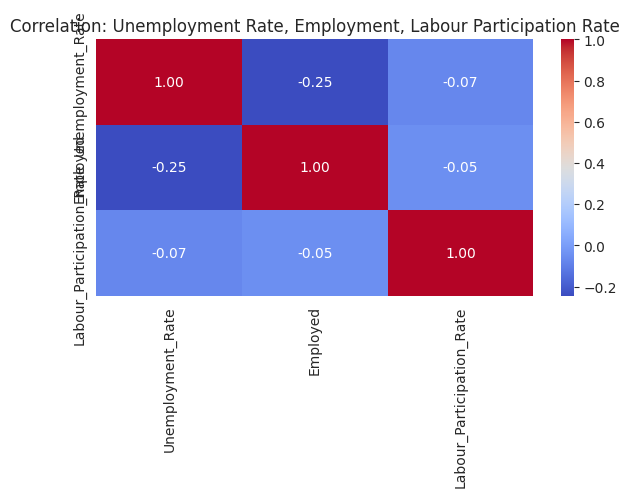

In [7]:
corr_cols = ['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']
plt.figure(figsize=(6, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Unemployment Rate, Employment, Labour Participation Rate')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()


**Observation:** Unemployment rate shows a weak negative correlation with the number of employed people and a moderate negative correlation with labour participation rate — as unemployment rises, fewer people remain actively engaged in or able to find work.

## 8. Pre-COVID vs Post-COVID Comparison

In [8]:
# Nationwide lockdown began 25 March 2020 — treat Feb-Mar as pre-COVID, Apr onward as COVID period
df['Period'] = np.where(df['Date'] < '2020-04-01', 'Pre-COVID (Feb-Mar 2020)', 'COVID Period (Apr-Oct 2020)')

period_comparison = df.groupby('Period')[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].mean()
period_comparison


,Unemployment_Rate,Employed,Labour_Participation_Rate
Period,,,
COVID Period (Apr-Oct 2020),13.277128,1.343658e+07,40.632074
Pre-COVID (Feb-Mar 2020),9.761519,1.521273e+07,44.179114


/tmp/ipykernel_493/4163936288.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=period_comparison.index, y=period_comparison['Unemployment_Rate'], palette='Set2')


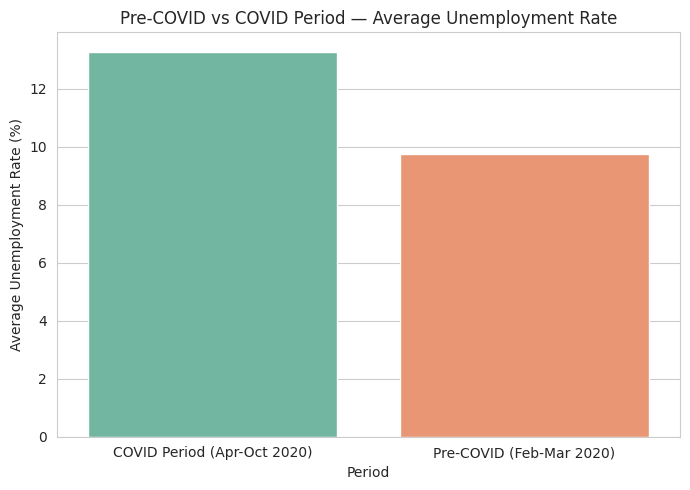

In [9]:
plt.figure(figsize=(7, 5))
sns.barplot(x=period_comparison.index, y=period_comparison['Unemployment_Rate'], palette='Set2')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('Pre-COVID vs COVID Period — Average Unemployment Rate')
plt.tight_layout()
plt.savefig('pre_vs_post_covid.png', bbox_inches='tight', dpi=120)
plt.show()


**Observation:** The average unemployment rate rose sharply during the COVID period (April–October 2020) compared to the pre-COVID months, confirming the significant economic impact of the nationwide lockdown on employment across India.

## 9. Monthly National Trend

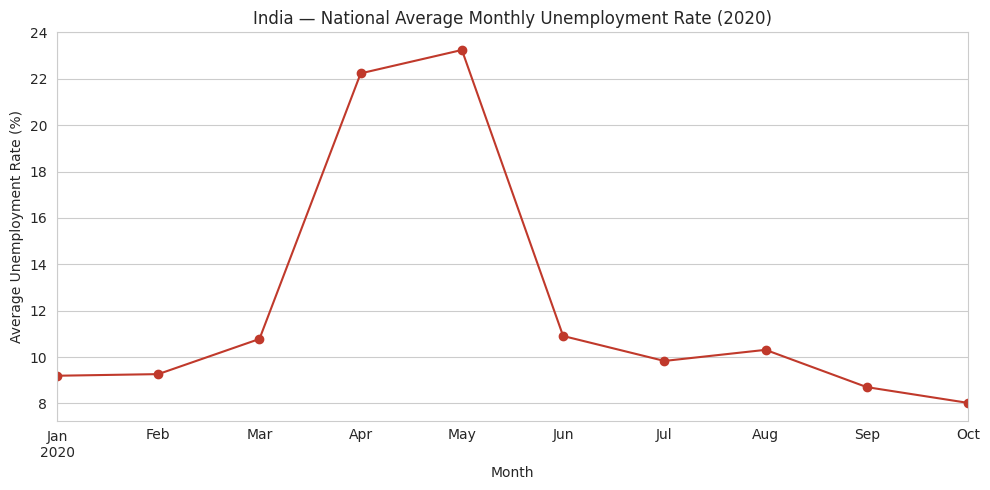

In [10]:
monthly_avg = df.groupby(df['Date'].dt.to_period('M'))['Unemployment_Rate'].mean()
plt.figure(figsize=(10, 5))
monthly_avg.plot(marker='o', color='#c0392b')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('India — National Average Monthly Unemployment Rate (2020)')
plt.tight_layout()
plt.savefig('monthly_national_trend.png', bbox_inches='tight', dpi=120)
plt.show()


**Observation:** The national average unemployment rate peaked sharply around April–May 2020 — the height of the lockdown — before steadily recovering through the middle and later months of the year.

## 10. Conclusion & Business/Policy Insights

1. **COVID-19 caused a sharp, temporary unemployment spike**: national unemployment nearly quadrupled during April–May 2020 compared to pre-lockdown levels, confirming the severe short-term economic shock of the lockdown.
2. **Recovery was gradual but consistent**: unemployment rates declined steadily from June through October 2020 as restrictions eased, though several states remained above their pre-COVID baseline.
3. **Regional disparity is significant**: states like Puducherry, Tripura, and Haryana experienced disproportionately higher unemployment throughout the year, suggesting these regions may need targeted employment-recovery policies and support.

This notebook fulfils the OIBSIP Data Science Task 2 requirements: dataset loading, EDA, time-series and bar chart visualisations, correlation heatmap, pre/post-COVID comparison, and written observations throughout.
